In [10]:
%pylab inline

Populating the interactive namespace from numpy and matplotlib


In [1]:
import grid2op as gp

In [2]:
from lightsim2grid import LightSimBackend
backend = LightSimBackend()

In [26]:
from grid2op.Agent import DoNothingAgent, RecoPowerlineAgent, PowerLineSwitch

In [40]:
env = gp.make('l2rpn_neurips_2020_track1_small', backend=backend)

In [41]:
env.parameters.HARD_OVERFLOW_THRESHOLD

2.0

In [43]:
# Performance is measured in rewards and durations
null_acc_rew, null_durs = [], []

env = gp.make('l2rpn_neurips_2020_track1_small', backend=backend)
null_agent = DoNothingAgent(env.action_space)
env.set_id(0)
env.seed(253)
for i in range(48):
    obs = env.reset()
    print(i, env.chronics_handler.get_name(), end=' ')
    done, acc_rew, dur = False, 0, 0
    while not done:
        ac = null_agent.act(obs, 0)
        obs, rew, done, _ = env.step(ac)
        acc_rew += rew
        dur += 1
    print(acc_rew, dur)
    null_acc_rew.append(acc_rew)
    null_durs.append(dur)

0 Scenario_april_000 955557.479675293 1019
1 Scenario_april_001 890450.4918212891 951
2 Scenario_april_002 83926.45532226562 79
3 Scenario_april_003 726616.0077514648 793
4 Scenario_april_004 638252.9977416992 665
5 Scenario_april_005 325107.3889770508 335
6 Scenario_april_006 1203881.476928711 1269
7 Scenario_april_007 724664.2921142578 772
8 Scenario_april_008 165166.775390625 180
9 Scenario_april_009 683837.069152832 743
10 Scenario_april_010 219802.36376953125 236
11 Scenario_april_011 503342.7897949219 533
12 Scenario_april_012 779440.2571411133 824
13 Scenario_april_013 105676.42028808594 98
14 Scenario_april_014 652651.6936035156 702
15 Scenario_april_015 115866.48815917969 105
16 Scenario_april_016 158983.59545898438 156
17 Scenario_april_017 518253.8059082031 517
18 Scenario_april_018 437517.92572021484 464
19 Scenario_april_019 390913.63928222656 412
20 Scenario_april_020 904176.8350219727 973
21 Scenario_april_021 354287.98828125 351
22 Scenario_april_022 1136067.682434082 1

<BarContainer object of 48 artists>

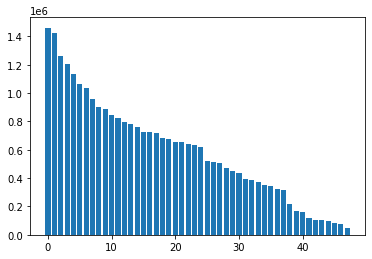

In [47]:
bar(range(48), sorted(null_acc_rew, reverse=True))

<BarContainer object of 48 artists>

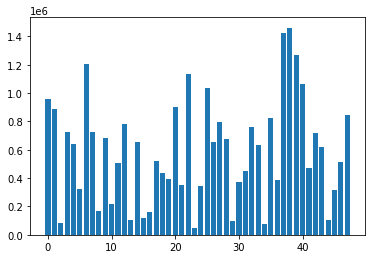

In [12]:
bar(range(48), null_acc_rew)

<BarContainer object of 48 artists>

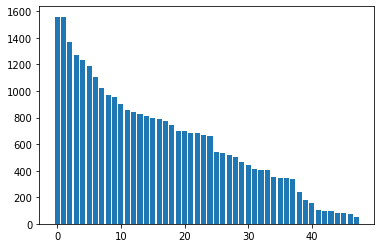

In [46]:
bar(range(48), sorted(null_durs, reverse=True))

<BarContainer object of 48 artists>

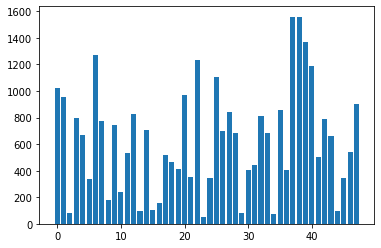

In [13]:
bar(range(48), null_durs)

In [48]:
# Performance is measured in rewards and durations
rec_acc_rew, rec_durs = [], []

env = gp.make('l2rpn_neurips_2020_track1_small', backend=backend)
rec_agent = RecoPowerlineAgent(env.action_space)
env.set_id(0)
env.seed(253)
for i in range(48):
    obs = env.reset()
    print(i, env.chronics_handler.get_name(), end=' ')
    done, acc_rew, dur = False, 0, 0
    while not done:
        ac = rec_agent.act(obs, 0)
        obs, rew, done, _ = env.step(ac)
        acc_rew += rew
        dur += 1
    print(acc_rew, dur)
    rec_acc_rew.append(acc_rew)
    rec_durs.append(dur)

0 Scenario_april_000 957902.0202636719 1022
1 Scenario_april_001 1137392.1100463867 1227
2 Scenario_april_002 1924161.845703125 2063
3 Scenario_april_003 1283668.093322754 1405
4 Scenario_april_004 370129.09899902344 369
5 Scenario_april_005 959471.7529296875 1031
6 Scenario_april_006 230959.42572021484 236
7 Scenario_april_007 507864.2657470703 534
8 Scenario_april_008 886080.6087646484 966
9 Scenario_april_009 719787.2687988281 785
10 Scenario_april_010 149503.18170166016 158
11 Scenario_april_011 1454128.7796020508 1561
12 Scenario_april_012 932255.3265380859 976
13 Scenario_april_013 350332.1945800781 354
14 Scenario_april_014 1349993.5166015625 1488
15 Scenario_april_015 343416.41876220703 346
16 Scenario_april_016 1441557.6090698242 1551
17 Scenario_april_017 821388.4053344727 842
18 Scenario_april_018 2261226.999572754 2421
19 Scenario_april_019 648226.6002807617 693
20 Scenario_april_020 339801.19177246094 358
21 Scenario_april_021 200809.8134765625 203
22 Scenario_april_022 52

<BarContainer object of 48 artists>

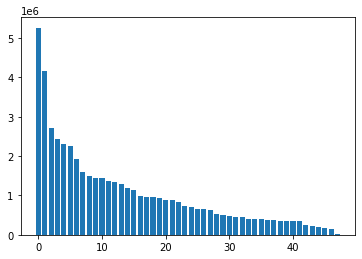

In [49]:
bar(range(48), sorted(rec_acc_rew, reverse=True))

<BarContainer object of 48 artists>

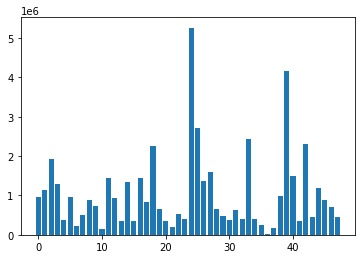

In [16]:
bar(range(48), rec_acc_rew)

<BarContainer object of 48 artists>

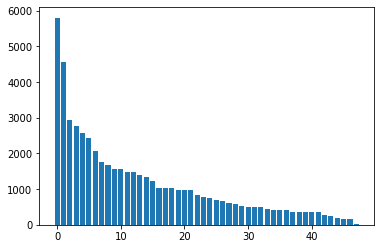

In [50]:
bar(range(48), sorted(rec_durs, reverse=True))

<BarContainer object of 48 artists>

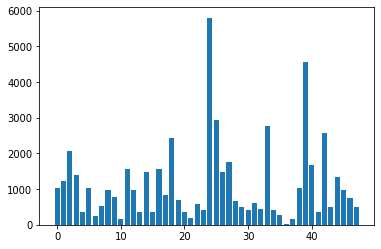

In [17]:
bar(range(48), rec_durs)

# Compare ReconnectAgent vs DoNothingAgent

In [51]:
median(rec_acc_rew), median(null_acc_rew)

(718607.455291748, 628629.8446960449)

In [52]:
mean(rec_acc_rew), mean(null_acc_rew)

(1041302.6805165609, 596656.7889722189)

In [53]:
median(rec_durs), median(null_durs)

(771.0, 663.0)

In [54]:
mean(rec_durs), mean(null_durs)

(1125.7083333333333, 633.1875)

In [28]:
def april_eval(agent, seed=253):
    # Performance is measured in rewards and durations
    acc_rews, durs = [], []

    env = gp.make('l2rpn_neurips_2020_track1_small', backend=backend)
    env.set_id(0)
    env.seed(seed)
    for i in range(48):
        obs = env.reset()
        print(i, env.chronics_handler.get_name(), end=' ')
        done, acc_rew, dur, rew = False, 0, 0, 0
        while not done:
            ac = agent.act(obs, rew)
            obs, rew, done, _ = env.step(ac)
            acc_rew += rew
            dur += 1
        print(acc_rew, dur)
        acc_rews.append(acc_rew)
        durs.append(dur)
    return acc_rews, durs

In [57]:
%%time
switch_agent = PowerLineSwitch(env.action_space)
swi_acc_rews, swi_durs = april_eval(switch_agent)

0 Scenario_april_000 462687.6687011719 494
1 Scenario_april_001 1683784.849975586 1841
2 Scenario_april_002 3059.9078369140625 4
3 Scenario_april_003 1625333.1052246094 1772
4 Scenario_april_004 1298910.5053710938 1405
5 Scenario_april_005 1009530.4352416992 1087
6 Scenario_april_006 454794.0256347656 476
7 Scenario_april_007 235403.0810546875 236
8 Scenario_april_008 485207.0110473633 531
9 Scenario_april_009 891370.2479858398 964
10 Scenario_april_010 715293.8955078125 782
11 Scenario_april_011 465991.04553222656 497
12 Scenario_april_012 721368.1012573242 767
13 Scenario_april_013 459666.1715698242 486
14 Scenario_april_014 899526.9111938477 974
15 Scenario_april_015 211137.3403930664 217
16 Scenario_april_016 1095100.1759033203 1174
17 Scenario_april_017 358246.29064941406 336
18 Scenario_april_018 336906.8508911133 346
19 Scenario_april_019 489848.5301513672 528
20 Scenario_april_020 253070.9603881836 269
21 Scenario_april_021 643739.4606933594 654
22 Scenario_april_022 717926.377

(673136.197054545, 464339.3571166992)

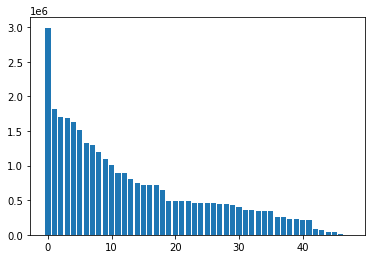

In [58]:
bar(range(48), sorted(swi_acc_rews, reverse=True))
mean(swi_acc_rews), median(swi_acc_rews)

(722.125, 502.0)

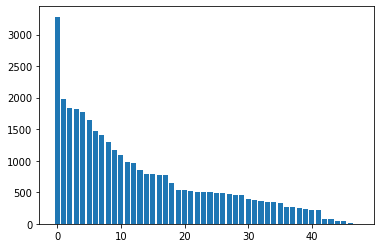

In [59]:
bar(range(48), sorted(swi_durs, reverse=True))
mean(swi_durs), median(swi_durs)

In [38]:
null_durs[0]

1022

In [39]:
null_acc_rew[0]

957878.1841430664

In [37]:
env.chronics_handler.data.prod_p.shape

(8063, 22)